# Module 10, Recitation 2: Nonlinear Optimization, Part 1 - Gradient Descent

by Sean Lo (`seanlo@mit.edu`) and Alexandre Jacquillat (`alexjacq@mit.edu`) 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import time

In [2]:
import zipfile, io

filename = "Data.zip"
with zipfile.ZipFile(filename, "r") as zip_ref:
    zip_ref.extractall("")  # extracts into folder "unzipped"

## Taylor approximations

In this section, we will see how to use Taylor expansions to approximate functions near a point.

Let's start with the following 1-D function $f$ defined on the domain $(0, \infty)$:
$$f(x) = \frac{1}{x} \sin(x)$$

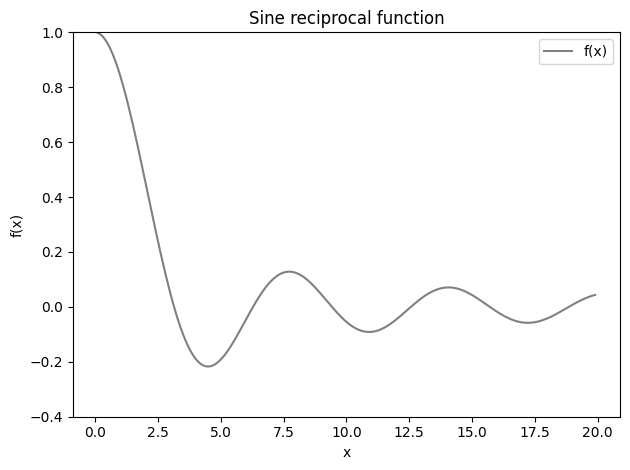

In [3]:
# Define the function
def sine_reciprocal(x):
    return np.sin(x) / x


# Plot the function
x_range = np.arange(0.1, 20, 0.1)
plt.figure(tight_layout=True)
plt.plot(x_range, sine_reciprocal(x_range), label="f(x)", color="gray")
plt.title("Sine reciprocal function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.ylim(-0.4, 1.0)
plt.legend()
plt.show()

We can obtain its Taylor expansion via computing its derivatives. Let's compute its first and second derivative via the product rule:
\begin{align*}
    f(x)
    & = x^{-1} \sin(x)
    \\
    f'(x)
    & = x^{-1} \cos(x) + (-x^{-2}) \sin(x)
    \\
    f''(x)
    & = x^{-1} (-\sin(x)) + (-x^{-2}) \cos(x) + (-x^{-2}) \cos(x) + (2x^{-3}) \sin(x)
\end{align*}

Here is the Taylor expansion for a univariate (1-D) function around a point $a$:
\begin{align*}
    f(x)
    & = f(a) + f'(a) (x-a) + \frac{f''(a)}{2} (x-a) + \dots
    \\
    & = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!} (x-a)^n
\end{align*}

This is an infinite series, and we can truncate this series whereever we want to get a "good enough" approximation around the point $a$ we care about. Hence, the first-degree Taylor approximation around $a$ is:
$$f(a) + f'(a) (x-a)$$
and the second-degree approximation around $a$ is:
$$f(a) + f'(a) (x-a) + \frac{f''(a)}{2} (x-a)^2$$

Let's visualize how that looks for our wavy function example!

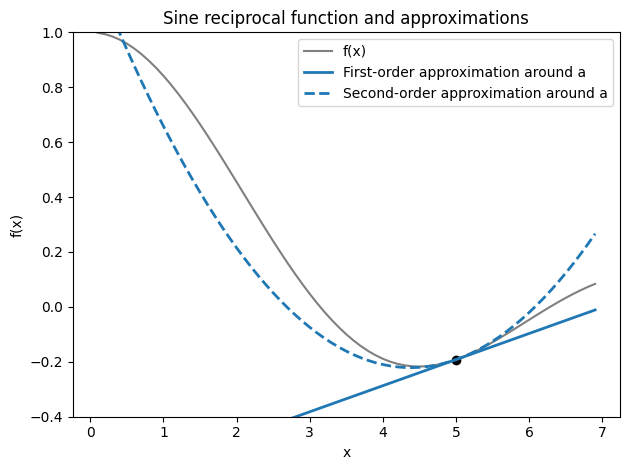

In [4]:
# Define the derivatives and Taylor approximations
def sine_reciprocal_derivative1(x):
    return np.cos(x) / x - np.sin(x) / x**2


def sine_reciprocal_approx1(x, a):
    return np.sin(a) / a + sine_reciprocal_derivative1(a) * (x - a)


def sine_reciprocal_derivative2(x):
    return -np.sin(x) / x - 2 * np.cos(x) / x**2 + 2 * np.sin(x) / x**3


def sine_reciprocal_approx2(x, a):
    return (
        sine_reciprocal_approx1(x, a)
        + sine_reciprocal_derivative2(a) * (x - a) ** 2 / 2
    )


# Plot the function
x_range = np.arange(start=0.1, stop=7, step=0.1)
a = 5
plt.figure(tight_layout=True)
plt.plot(
    x_range,
    sine_reciprocal(x_range),
    label="f(x)",
    color="gray",
)
plt.plot([a], [sine_reciprocal(a)], color="black", marker="o", label=None)
plt.plot(
    x_range,
    sine_reciprocal_approx1(x_range, a),
    label="First-order approximation around a",
    linewidth=2,
    color="tab:blue",
)
plt.plot(
    x_range,
    sine_reciprocal_approx2(x_range, a),
    label="Second-order approximation around a",
    linewidth=2,
    color="tab:blue",
    linestyle="--",
)
plt.title(label="Sine reciprocal function and approximations")
plt.xlabel(xlabel="x")
plt.ylabel(ylabel="f(x)")
plt.ylim(ymin=-0.4, ymax=1.0)
plt.legend()
plt.savefig(fname="Data/figures/sine_reciprocal_approx.png")
plt.show()

You can see that as the number of terms included in the approximation goes up, we can get closer and closer to our function.

## Necessary and sufficient optimality conditions

From lecture, we saw that we can determine if our point $x^*$ is a local minimum of the function $f$ depending on the first and second derivatives at that point:
1. If ($f$ is twice continuously differentiable and) $x^*$ is a local min. of $f$, then $\nabla f(x^*) = 0$ and $\nabla^2 f(x^*) \succeq 0$.
2. If ($f$ is twice continuously differentiable and) $\nabla f(x^*) = 0$ and $\nabla^2 f(x^*) \succ 0$, then $x^*$ is a local min. of $f$.

The first condition is called the **necessary** condition because it lists the required conditions for $x^*$ to possibly be a local min. of $f$. The second condition, in turn, is the **sufficient** condition because it lists conditions under which you can be sure that $x^*$ is a local min of $f$. There is a subtle difference between the two!

One more thing: in our example so far, $f$ is one-dimensional so the gradient and the Hessian are simply the first derivative and the second derivative respectively. The conditions $\nabla^2 f(x^*) \succeq 0$ and $\nabla^2 f(x^*) \succ 0$ are the multiple-dimension generalizations of the second derivative being nonnegative and strictly positive respectively.

Let's go back to our example and find points which could be local minima: if $x^*$ were a local minimum of $f$, then by the necessary condition:
\begin{align*}
    && x^{-1} \cos(x) + (-x^{-2}) \sin(x) & = 0
    \\
    \implies && x \cos(x) & = \sin(x)
    \quad \text{(since $x > 0$)}
    \\
    \implies && x & = 4.493..., 7.725..., 10.904...,
\end{align*}

In [5]:
critical_points = [4.49340945, 7.72525183, 10.90412165]
for x_sol in critical_points:
    print(f"\nEvaluating derivatives at x = {x_sol:8.5f}")
    print(f"First derivative:  {sine_reciprocal_derivative1(x_sol): 08.5f}")
    deriv2 = sine_reciprocal_derivative2(x_sol)
    print(f"Second derivative: {deriv2: 08.5f}", end=" ")
    if deriv2 > 0:
        print(f"is positive, so x = {x_sol:8.5f} is a local minimum!")
    elif deriv2 < 0:
        print(f"is negative, so x = {x_sol:8.5f} is a local maximum!")
    else:
        print(f"is zero, so x = {x_sol:8.5f} is a saddle point!")


Evaluating derivatives at x =  4.49341
First derivative:  -0.00000
Second derivative:  0.21723 is positive, so x =  4.49341 is a local minimum!

Evaluating derivatives at x =  7.72525
First derivative:   0.00000
Second derivative: -0.12837 is negative, so x =  7.72525 is a local maximum!

Evaluating derivatives at x = 10.90412
First derivative:  -0.00000
Second derivative:  0.09133 is positive, so x = 10.90412 is a local minimum!


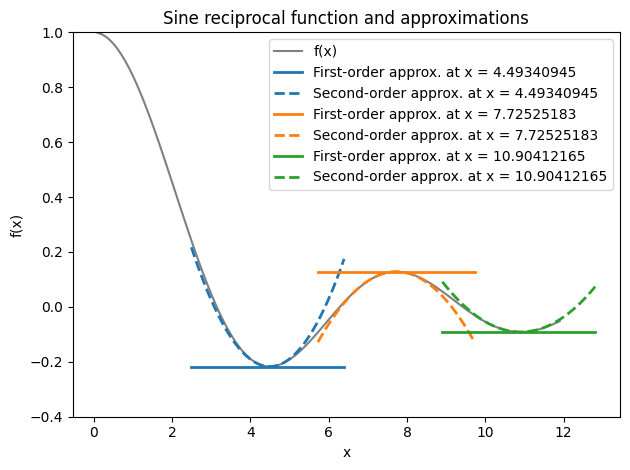

In [6]:
# Plot the function
x_range = np.arange(0.1, 12, 0.1)
plt.figure(tight_layout=True)
plt.plot(
    x_range,
    sine_reciprocal(x_range),
    label="f(x)",
    color="gray",
)

for i, x_sol in enumerate(critical_points):
    x_range_modified = np.arange(x_sol - 2, x_sol + 2, 0.1)
    plt.plot(
        x_range_modified,
        sine_reciprocal_approx1(x_range_modified, x_sol),
        label=f"First-order approx. at x = {x_sol}",
        linewidth=2,
        color=mpl.color_sequences["tab10"][i],
    )
    plt.plot(
        x_range_modified,
        sine_reciprocal_approx2(x_range_modified, x_sol),
        label=f"Second-order approx. at x = {x_sol}",
        linewidth=2,
        color=mpl.color_sequences["tab10"][i],
        linestyle="--",
    )

plt.title("Sine reciprocal function and approximations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.ylim(-0.4, 1.0)
plt.legend()
plt.savefig("Data/figures/sine_reciprocal_critical_points.png")
plt.show()

## Gradient descent: choices in step size

Now, let's look at gradient descent! Gradient descent is an algorithm for finding the minimum of a function, where at each step it travels a short distance in the "direction of most negative gradient". This is the algorithm:

1. Initialization: starting point $x^0 \in \mathbb{R}^n$, step size $\alpha > 0$, iteration counter $k = 0$
2. Repeat until termination:
    1. Move to next point $$x^{k+1} \leftarrow x^k - \alpha \cdot \nabla f(x^k)$$
    2. Update iteration counter $k \leftarrow k + 1$



Why is there a negative sign in the expression for $x^{k+1}$? Here is a formulaic explanation and a intuitive explanation:
- Formulaic: If you take the Taylor expansion of $f(x^k - \alpha \cdot \nabla f(x^k))$ around $x^k$, you get a value which you can show to be less than $f(x^k)$, for $\alpha$ small enough.
- Intuitive: In 1 dimension, if the slope at your current iterate $x^k$ is positive, this means that your function is "upward-sloping" at $x^k$, and you should move backwards in order to find the minimum i.e. make $x^{k+1}$ left of $x^k$. Vice versa if the current slope is negative, your function is locally downward-sloping and you should move forwards i.e. make $x^{k+1}$ right of $x^k$.
- Building on the intuitive explanation more: in higher dimensions, the term $- \nabla f(x^k)$ is also known as the **descent direction** $d^k$. Now we can see that $x^k + \alpha d^k$ is where you end up, after starting at point $x^k$ and travelling $\alpha$ units in the $d^k$ direction!

Let's see this in action! We're now going to be looking at two two-dimensional examples:
- A quadratic function given by $$f(x_1, x_2) := 5x_1^2 + x_2^2 + 4 x_1 x_2 - 14 x_1 - 6 x_2 + 20$$
- And a more complicated function known as [Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function), given by $$100(x_2 - x_1^2)^2 + (1 - x_1)^2$$

In [7]:
def cost_function_quadratic(x):
    return 5 * x[0] ** 2 + x[1] ** 2 + 4 * x[0] * x[1] - 14 * x[0] - 6 * x[1] + 20


def gradient_quadratic(x):
    return np.array(
        [
            10 * x[0] + 4 * x[1] - 14,
            2 * x[1] + 4 * x[0] - 6,
        ]
    )

In [8]:
def cost_function_rosenbrock(x):
    return 100 * (x[1] - x[0] ** 2) ** 2 + (1 - x[0]) ** 2


def gradient_rosenbrock(x):
    return np.array(
        [
            -400 * x[0] * (x[1] - x[0] ** 2) - 2 * (1 - x[0]),
            200 * (x[1] - x[0] ** 2),
        ]
    )

Here is a Python function that implements gradient descent. It takes as arguments the cost function you want to minimize, its gradient, a starting point `initial_x`, the step size `alpha`, and optional termination parameters.

In [9]:
def gradient_descent(
    cost_function,
    gradient,
    initial_x,
    alpha,
    max_iter=1000,
    epsilon=1e-5,
):
    # Initialization
    x = np.array(initial_x)
    k = 0
    x_history = []
    cost_history = []
    gradient_norm_history = []

    while True:
        # Find descent direction d
        gradient_val = gradient(x)
        d = -gradient_val
        cost_function_val = cost_function(x)
        gradient_norm = np.linalg.norm(gradient_val)

        # Update history
        x_history.append(x.copy())
        cost_history.append(cost_function_val)
        gradient_norm_history.append(gradient_norm)

        # Termination condition
        if gradient_norm < epsilon:
            break
        if k >= max_iter:
            break

        # Update x
        x = x + alpha * d
        # Increment iteration count
        k += 1

    return {
        "x": np.array(x_history),
        "cost": np.array(cost_history),
        "gradient_norm": np.array(gradient_norm_history),
    }

Let's use this function to run gradient descent on the quadratic function:

In [10]:
initial_x = [20, -100]
alpha = 0.1
start_time = time.time()
results_quadratic = gradient_descent(
    cost_function_quadratic,
    gradient_quadratic,
    initial_x,
    alpha,
)
print(f"Time taken: {time.time() - start_time:.4f} seconds")

Time taken: 0.0050 seconds


Let's visualize the results:

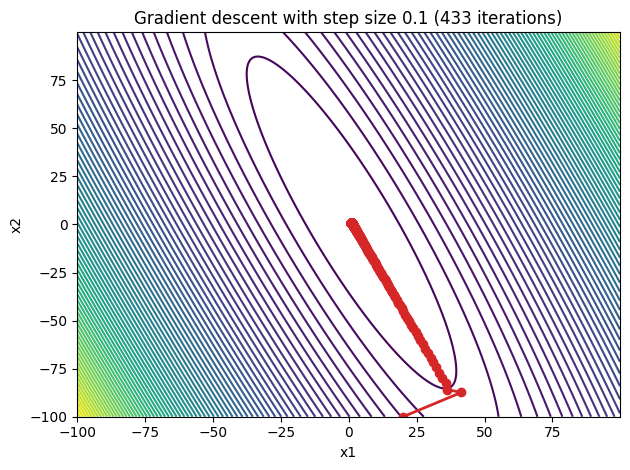

In [11]:
# Define the range of x and y values
x_range = np.arange(-100, 100, 0.1)
y_range = np.arange(-100, 100, 0.1)
X, Y = np.meshgrid(x_range, y_range)
Z = np.array([[cost_function_quadratic([x, y]) for x in x_range] for y in y_range])

plt.figure(tight_layout=True)
plt.contour(X, Y, Z, levels=100, cmap="viridis")
plt.plot(
    results_quadratic["x"][:, 0],
    results_quadratic["x"][:, 1],
    color="tab:red",
    linewidth=2,
    marker="o",
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(
    f"Gradient descent with step size {alpha} ({len(results_quadratic['cost'])} iterations)"
)
plt.savefig(f"Data/figures/contour_quadratic_{alpha}.png")
plt.show()

Let's repeat and see what happens for different step sizes!

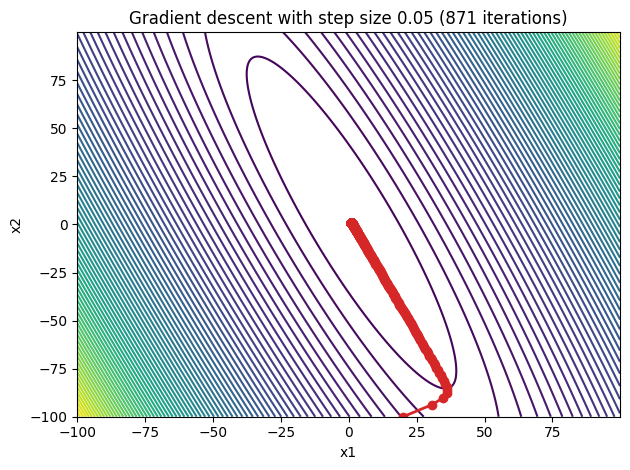

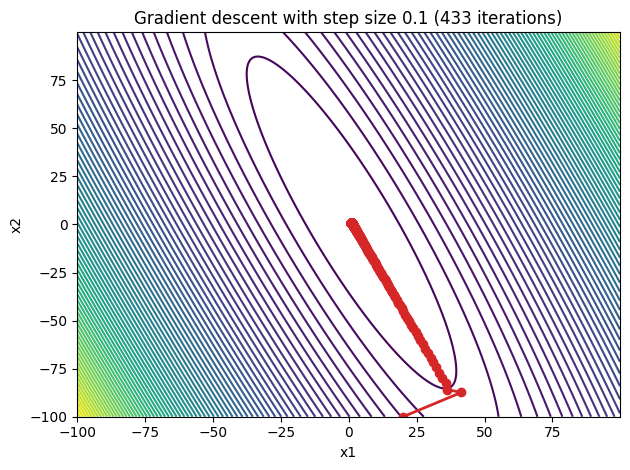

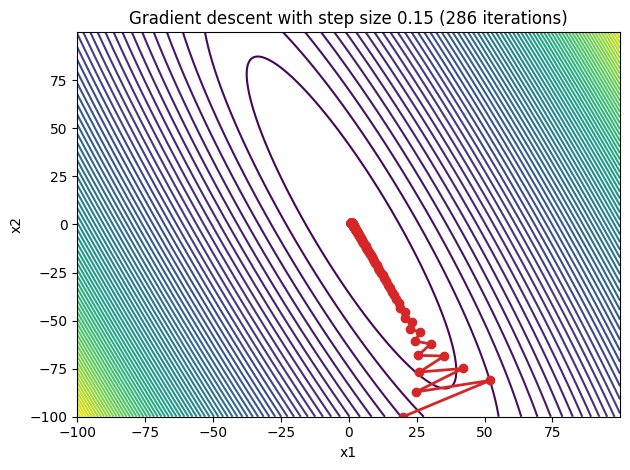

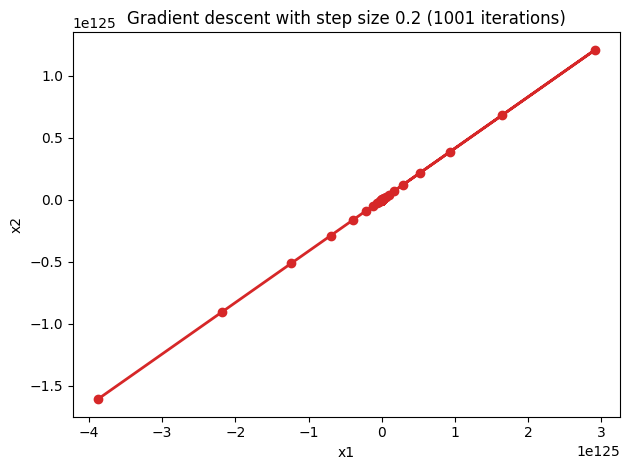

In [13]:
# Define the range of x and y values
x_range = np.arange(-100, 100, 0.1)
y_range = np.arange(-100, 100, 0.1)
X, Y = np.meshgrid(x_range, y_range)
Z = np.array([[cost_function_quadratic([x, y]) for x in x_range] for y in y_range])

results_quadratic = {}
for alpha in [0.05, 0.1, 0.15, 0.2]:
    initial_x = [20, -100]
    results_quadratic[alpha] = gradient_descent(
        cost_function_quadratic,
        gradient_quadratic,
        initial_x,
        alpha,
    )

    plt.figure(tight_layout=True)
    plt.contour(X, Y, Z, levels=100, cmap="viridis")
    plt.plot(
        results_quadratic[alpha]["x"][:, 0],
        results_quadratic[alpha]["x"][:, 1],
        color="tab:red",
        linewidth=2,
        marker="o",
    )
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(
        f"Gradient descent with step size {alpha} ({len(results_quadratic[alpha]['cost'])} iterations)"
    )
    plt.savefig(f"Data/figures/contour_quadratic_{alpha}.png")
    plt.show()

From the above example we see how different step sizes affects the behaviour of gradient descent.
- For small step sizes, GD converges to the minimum $(0, 0)$ but it can take many iterations to do so.
- For higher step sizes, GD can converge faster, but it "zig-zags" and changes direction frequently.
- If the step size is too large, GD might not be able to converge!

Let's repeat what we've done for the Rosenbrock function.

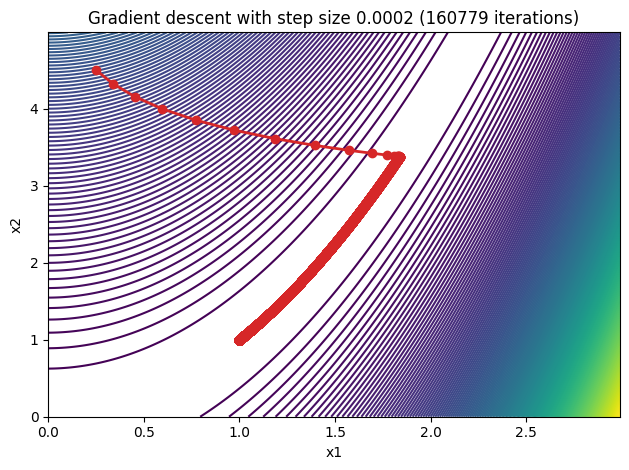

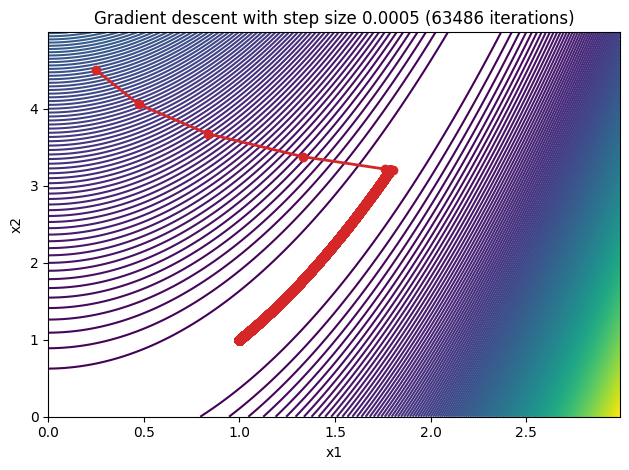

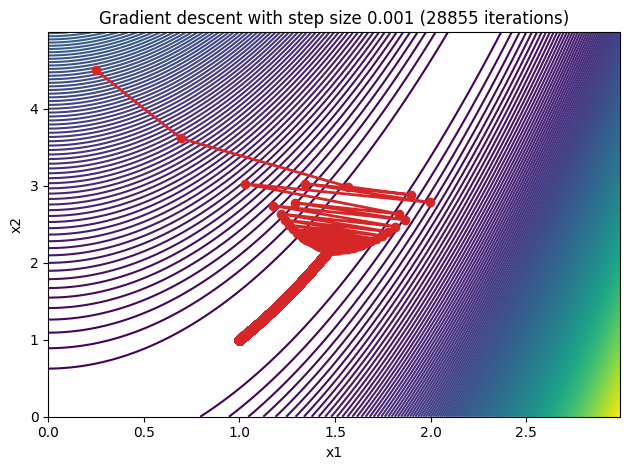

In [14]:
# Define the range of x and y values
x_range = np.arange(0, 3, 0.01)
y_range = np.arange(0, 5, 0.01)
X, Y = np.meshgrid(x_range, y_range)
Z = np.array([[cost_function_rosenbrock([x, y]) for x in x_range] for y in y_range])

results_rosenbrock = {}
for alpha in [0.0002, 0.0005, 0.001]:
    initial_x = [0.25, 4.5]
    results_rosenbrock[alpha] = gradient_descent(
        cost_function_rosenbrock,
        gradient_rosenbrock,
        initial_x,
        alpha,
        max_iter=1000000,  # Don't terminate early
    )

    plt.figure(tight_layout=True)
    plt.contour(X, Y, Z, levels=200, cmap="viridis")
    plt.plot(
        results_rosenbrock[alpha]["x"][:, 0],
        results_rosenbrock[alpha]["x"][:, 1],
        color="tab:red",
        linewidth=2,
        marker="o",
    )
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(
        f"Gradient descent with step size {alpha} ({len(results_rosenbrock[alpha]['cost'])} iterations)"
    )
    plt.savefig(f"Data/figures/contour_rosenbrock_{alpha}.png")
    plt.show()

We see the same story: a lower step size results in slower (but more stable) convergence, while a larger step size results in a convergence path that has more oscillations. Set your step size too large, and you might even diverge!

Similarly, if your initial point changes, gradient descent may converge to different local minima! This can happen whenever your function is non-convex. If your function is convex, local minima must also be global minima.